# Datenaufbereitung: OpenFlights-Flugroutennetz → PyG-Split

Dieses Notebook bereitet das **weltweite Flugroutennetz von OpenFlights** für die Link Prediction mit GINE und
GATv2 auf. Die Modell-Notebooks (`GINE_OpenFlights.ipynb`, `GATV2_OpenFlights.ipynb`) laden ausschließlich die hier
gespeicherte Datei `processed/openflights_split.pt`.

**Was ein Datensatz für Link Prediction mit GNNs braucht:**

| Eigenschaft | Warum |
|---|---|
| Struktur, die sich nicht aus Koordinaten ablesen lässt | sonst löst schon die Luftlinie die Aufgabe |
| unterschiedliche Rollen der Knoten (z. B. Hubs) | Message Passing kann den Grad und die Nachbarschaft erkennen |
| überlappende Nachbarschaften (Dreiecke, gemeinsame Nachbarn) | Message Passing „sieht“ über 2–3 Schritte, wer zusammengehört |
| Features, die zwischen Knoten verallgemeinern | sonst lernt das Modell einzelne Knoten auswendig |

**OpenFlights** erfüllt alle vier Punkte und passt zum Thema Verkehr/Mobilität:

- **Quelle:** [openflights.org/data](https://openflights.org/data), Lizenz Open Database License (ODbL).
  Dateien `airports.dat` (Flughäfen) und `routes.dat` (Routen, Stand Juni 2014, eine Zeile pro Airline und
  Richtung) aus dem GitHub-Repository `jpatokal/openflights`.
- **Knoten:** Flughäfen mit mindestens einer Route. **Kanten:** Flughafenpaare, zwischen denen mindestens eine
  Airline fliegt (ungerichtet, im PyG-Graphen in beiden Richtungen).
- **Knotenfeatures:** Position auf der Erdkugel, Höhe, Zeitzone, Weltregion.
- **Kantenfeatures:** Entfernung, Zahl der Airlines, Zahl der Routen-Einträge, Zahl der Flugzeugtypen,
  Codeshare-Anteil, beide Richtungen beflogen. GINE und GATv2 sind über `edge_dim` genau für solche Kantenfeatures
  gebaut.
- **Aufgabe:** Gegeben das Netz ohne einen Teil der Routen, welche fehlenden Flughafenpaare sind echte Routen?
  Das entspricht der Frage „Welche Verbindung würde eine Airline einrichten?“

Die Logik liegt im Paket `gnn_pipeline/`: `openflights.py` (Download, Parsing, Features, Graph), `graph.py`
(Split, Negativ-Sampling), `io.py` (Speichern), `evaluation.py` (Baselines).

In [7]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from gnn_pipeline import (
    ensure_openflights, load_openflights, OpenFlightsConfig, OPENFLIGHTS_NODE_FEATURES,
    build_openflights_graph, split_graph, GraphBundle, save_bundle, heuristic_baselines,
)

data_dir = ensure_openflights()          # lädt nur, wenn die Dateien fehlen
frames = load_openflights(data_dir)      # frames.airports, frames.routes, frames.pairs
airports, routes, pairs = frames.airports, frames.routes, frames.pairs

display(airports[["airport_id", "name", "city", "country", "iata", "lat", "lon", "altitude_ft", "utc_offset", "region"]].head())
display(routes[["airline", "src_code", "dst_code", "codeshare", "stops", "equipment"]].head())
display(pairs.head())

C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\gurke\PycharmProjects\MethodenDerKI_GraphEmbedding\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Daten liegen in: OpenFlights_raw
OpenFlights: 3214 Flughäfen mit Routen, 67663 Routen-Einträge (66770 gültig) -> 18858 ungerichtete Flughafenpaare


,airport_id,name,city,country,iata,lat,lon,altitude_ft,utc_offset,region
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,-6.081690,145.391998,5282,10.0,Pacific
1,2,Madang Airport,Madang,Papua New Guinea,MAG,-5.207080,145.789001,20,10.0,Pacific
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,-5.826790,144.296005,5388,10.0,Pacific
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,-6.569803,146.725977,239,10.0,Pacific
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,-9.443380,147.220001,146,10.0,Pacific


,airline,src_code,dst_code,codeshare,stops,equipment
0,2B,AER,KZN,,0,CR2
1,2B,ASF,KZN,,0,CR2
2,2B,ASF,MRV,,0,CR2
3,2B,CEK,KZN,,0,CR2
4,2B,CEK,OVB,,0,CR2


,u_idx,v_idx,n_airlines,n_route_entries,codeshare_share,n_aircraft_types,bidirectional,distance_km
0,0,1,1,2,0.0,1,1,106.713899
1,0,2,1,2,0.0,2,1,124.481044
2,0,3,1,2,0.0,1,1,157.101505
3,0,4,2,4,0.0,3,1,424.592807
4,1,2,1,2,0.0,1,1,179.035991


In [8]:
# Gemeinsamer Plot-Stil (Farben wie in gnn_pipeline/training.py, farbfehlsicht-sicher).
# Farben explizit gesetzt, weil PyCharm Notebook-Plots sonst mit dunklem Hintergrund rendert.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, MUTED, GRID, AXIS = "#ffffff", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="both"):
    ax.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    if grid_axis:
        ax.grid(True, axis=grid_axis, color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelcolor=INK, length=0)
    if title:
        ax.set_title(title, loc="left", color=INK, fontsize=12)
    if xlabel:
        ax.set_xlabel(xlabel, color=INK)
    if ylabel:
        ax.set_ylabel(ylabel, color=INK)
    return ax

def figure(*args, **kwargs):
    fig, axes = plt.subplots(*args, **kwargs)
    fig.patch.set_facecolor(SURFACE)
    return fig, axes

# Explorative Analyse

Die Plots dienen dem Verständnis der Daten und haben keinen Einfluss auf den Split.

## Kennzahlen

Grad = Zahl der Flughäfen, mit denen ein Flughafen direkt verbunden ist (ungerichtet).

In [9]:
G = nx.Graph()
G.add_nodes_from(airports["node_idx"])
G.add_edges_from(zip(pairs["u_idx"], pairs["v_idx"]))
degree = pd.Series(dict(G.degree())).sort_index()
airports["degree"] = degree.values

largest_cc = max(nx.connected_components(G), key=len)
summary = pd.Series({
    "Flughäfen (Knoten)": G.number_of_nodes(),
    "Flughafenpaare mit Route (Kanten)": G.number_of_edges(),
    "Routen-Einträge (Airline × Richtung)": len(routes),
    "Airlines": routes["airline"].nunique(),
    "Länder": airports["country"].nunique(),
    "mittlerer Grad": round(degree.mean(), 2),
    "Median Grad": int(degree.median()),
    "maximaler Grad": int(degree.max()),
    "Dichte": f"{nx.density(G):.5f}",
    "Zusammenhangskomponenten": nx.number_connected_components(G),
    "Anteil größte Komponente": f"{len(largest_cc) / G.number_of_nodes():.1%}",
    "beide Richtungen beflogen": f"{pairs['bidirectional'].mean():.1%}",
})
summary.to_frame("OpenFlights")

,OpenFlights
Flughäfen (Knoten),3214
Flughafenpaare mit Route (Kanten),18858
Routen-Einträge (Airline × Richtung),66770
Airlines,566
Länder,225
mittlerer Grad,11.73
Median Grad,3
maximaler Grad,248
Dichte,0.00365
Zusammenhangskomponenten,7


## Weltkarte des Netzes

Jede Linie ist ein Flughafenpaar mit mindestens einer Route (gerade Linie in Längen-/Breitengrad, Routen über die
Datumsgrenze sind ausgelassen). Punktgröße und Farbe zeigen den Grad: Wenige große Hubs (Amsterdam, Frankfurt,
Paris, Istanbul, Atlanta, Peking, …) bündeln einen großen Teil der Verbindungen. Beschriftet ist der jeweils größte
Hub einer Gegend. Diese Hub-Struktur ist genau das Signal, das ein
GNN über Message Passing lernen kann.

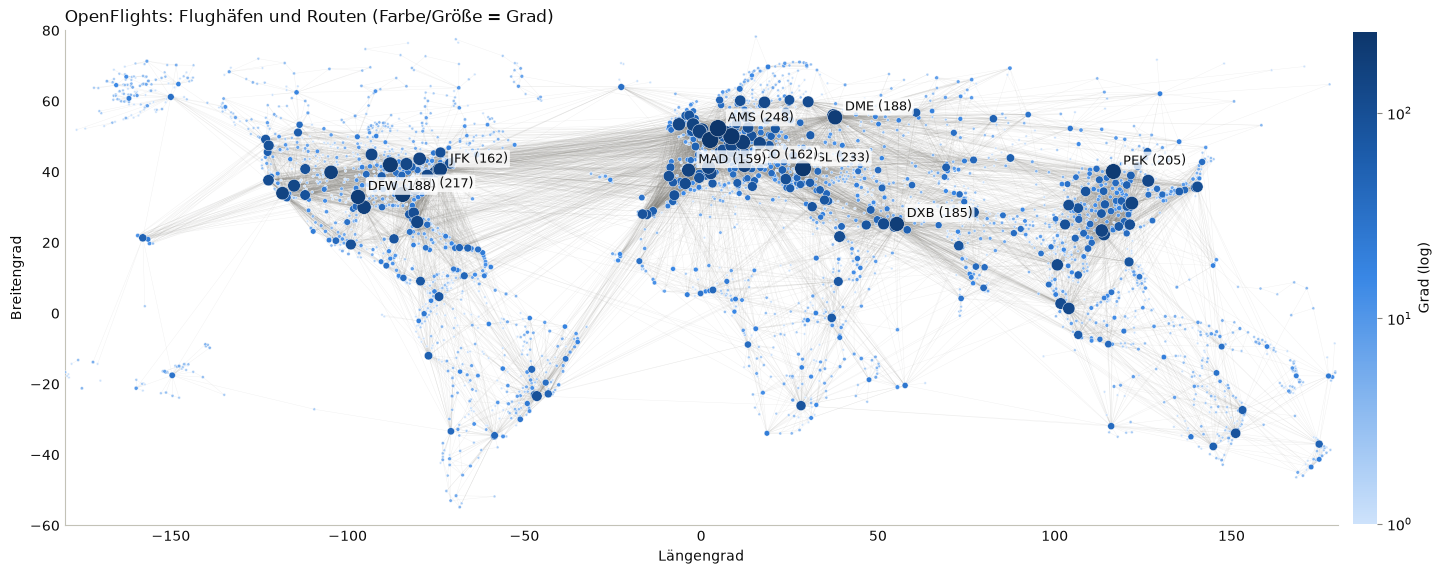

In [10]:
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, LogNorm

lon, lat = airports["lon"].values, airports["lat"].values
segments = np.stack([np.c_[lon[pairs["u_idx"]], lat[pairs["u_idx"]]],
                     np.c_[lon[pairs["v_idx"]], lat[pairs["v_idx"]]]], axis=1)
segments = segments[np.abs(segments[:, 0, 0] - segments[:, 1, 0]) < 180]   # Datumsgrenze auslassen

blues = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
fig, ax = figure(figsize=(16, 8.5))
ax.add_collection(LineCollection(segments, colors=MUTED, linewidths=0.3, alpha=0.12))
order = np.argsort(airports["degree"].values)     # große Hubs zuletzt zeichnen (oben)
sc = ax.scatter(lon[order], lat[order], c=airports["degree"].values[order], cmap=blues, norm=LogNorm(1, degree.max()),
                s=3 + airports["degree"].values[order] * 0.6, edgecolors=SURFACE, linewidths=0.3, zorder=3)
labeled = []   # nur Hubs beschriften, die mindestens 12 Grad von einem bereits beschrifteten entfernt liegen
for _, r in airports.nlargest(40, "degree").iterrows():
    if len(labeled) == 10 or any(np.hypot(r["lon"] - a, r["lat"] - b) < 12 for a, b in labeled):
        continue
    labeled.append((r["lon"], r["lat"]))
    ax.annotate(f"{r['iata']} ({r['degree']})", (r["lon"], r["lat"]), xytext=(7, 5), textcoords="offset points",
                fontsize=9, color=INK, zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", facecolor=SURFACE, edgecolor="none", alpha=0.8))
style(ax, "OpenFlights: Flughäfen und Routen (Farbe/Größe = Grad)", "Längengrad", "Breitengrad", grid_axis=None)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 80); ax.set_aspect("equal")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.01)
cbar.set_label("Grad (log)", color=INK); cbar.outline.set_visible(False); cbar.ax.tick_params(colors=MUTED, labelcolor=INK)
fig.tight_layout()
plt.show()

## Gradverteilung

Komplementäre kumulative Verteilung (Anteil der Knoten mit Grad ≥ k), doppelt logarithmisch. Die Kurve fällt über
drei Größenordnungen fast linear, ein *heavy-tailed* (annähernd skalenfreies) Netz. Die Hälfte der Flughäfen hat
höchstens drei Verbindungen, einige Hubs haben mehrere hundert.

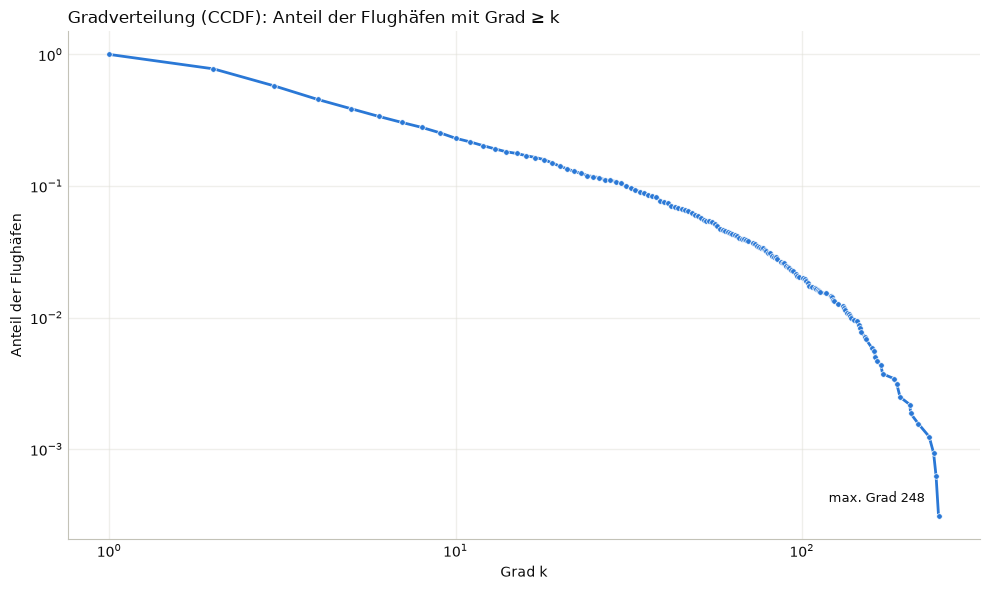

In [11]:
values = np.sort(degree.values)
k = np.unique(values)
p = np.array([(values >= x).mean() for x in k])

fig, ax = figure(figsize=(10, 6))
ax.plot(k, p, "-o", color=BLUE, linewidth=2, markersize=4, markeredgecolor=SURFACE, markeredgewidth=0.5)
ax.annotate(f"max. Grad {int(degree.max())}", (k[-1], p[-1]), xytext=(-10, 10), textcoords="offset points",
            ha="right", fontsize=9, color=INK)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "Gradverteilung (CCDF): Anteil der Flughäfen mit Grad ≥ k", "Grad k", "Anteil der Flughäfen")
fig.tight_layout()
plt.show()

## Strukturvergleich: Warum Link Prediction hier lernbar ist

Alle Werte sind auf dem ungerichteten Graphen berechnet.

- **Clustering-Koeffizient / Dreiecke:** Die Nachbarn eines Flughafens sind oft auch untereinander verbunden.
- **Kanten mit gemeinsamen Nachbarn:** Anteil der Kanten (u, v), bei denen u und v mindestens einen gemeinsamen
  Nachbarn haben. Nur wenn dieser Anteil hoch ist, kann Message Passing über 2–3 Schritte „sehen“, dass zwei
  Knoten zusammengehören.
- **Streuung des Grads:** Der Grad reicht von 1 bis 248 (Std. 25), die Knoten haben also sehr unterschiedliche
  Rollen.
- **Grad-Assortativität:** ≈ 0. Flughäfen verbinden sich also nicht bevorzugt mit gleich großen
  Flughäfen. Kleine Flughäfen hängen an Flughäfen jeder Größe, große Hubs sind zusätzlich dicht untereinander
  vernetzt (siehe Hexbin-Plot unten).

In [12]:
def structure_stats(graph):
    triangles = sum(nx.triangles(graph).values()) // 3
    adj = {n: set(graph[n]) for n in graph}
    with_common = np.mean([len(adj[u] & adj[v]) > 0 for u, v in graph.edges()])
    deg = np.array([d for _, d in graph.degree()])
    return {
        "Knoten": graph.number_of_nodes(),
        "Kanten (ungerichtet)": graph.number_of_edges(),
        "mittlerer Grad": round(deg.mean(), 2),
        "maximaler Grad": int(deg.max()),
        "Std. des Grads": round(deg.std(), 2),
        "Dreiecke": triangles,
        "mittlerer Clustering-Koeffizient": round(nx.average_clustering(graph), 3),
        "Kanten mit ≥ 1 gemeinsamen Nachbarn": f"{with_common:.1%}",
        "Grad-Assortativität": round(nx.degree_assortativity_coefficient(graph), 3),
    }

pd.Series(structure_stats(G)).to_frame("OpenFlights")

,OpenFlights
Knoten,3214
Kanten (ungerichtet),18858
mittlerer Grad,11.73
maximaler Grad,248
Std. des Grads,25.03
Dreiecke,100657
mittlerer Clustering-Koeffizient,0.492
Kanten mit ≥ 1 gemeinsamen Nachbarn,93.8%
Grad-Assortativität,-0.017


## Die größten Hubs

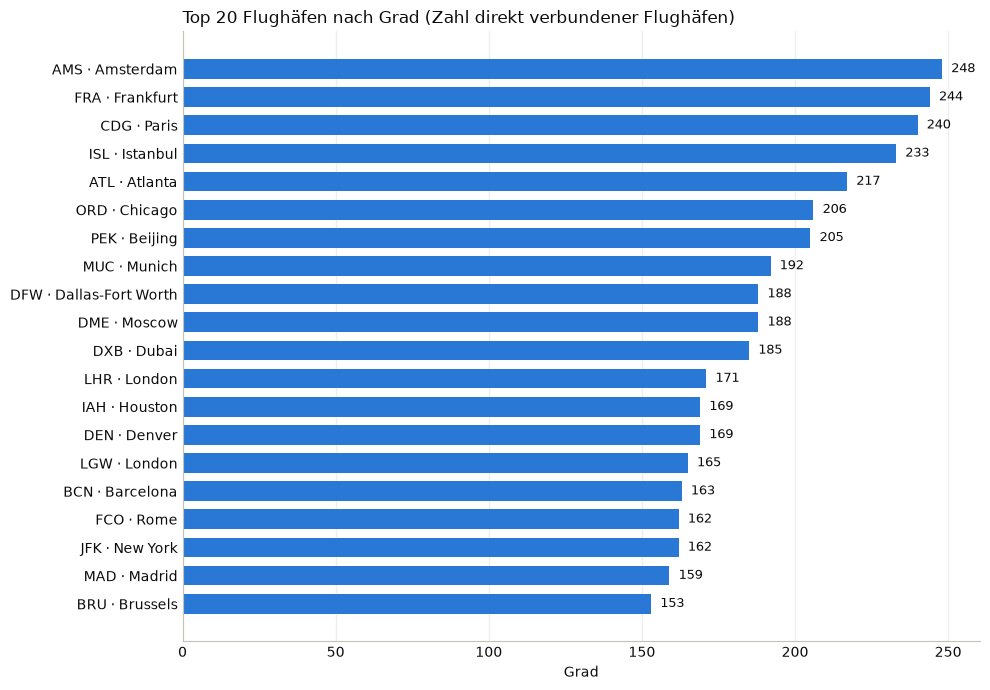

In [13]:
top = airports.nlargest(20, "degree").iloc[::-1]
fig, ax = figure(figsize=(10, 7))
ax.barh(top["iata"] + " · " + top["city"], top["degree"], color=BLUE, height=0.7)
for y, v in enumerate(top["degree"]):
    ax.text(v + 3, y, str(v), va="center", fontsize=9, color=INK)
style(ax, "Top 20 Flughäfen nach Grad (Zahl direkt verbundener Flughäfen)", "Grad", None, grid_axis="x")
fig.tight_layout()
plt.show()

## Flughäfen und Routen nach Weltregion

Die Region stammt aus dem Präfix der Zeitzonen-Datenbank (`Europe/Berlin` → `Europe`). Sie ist ein Knotenfeature
(One-Hot). Rechts der Anteil der Routen, die innerhalb derselben Region bleiben: Die meisten Verbindungen sind
regional, das Netz hat also eine Community-Struktur.

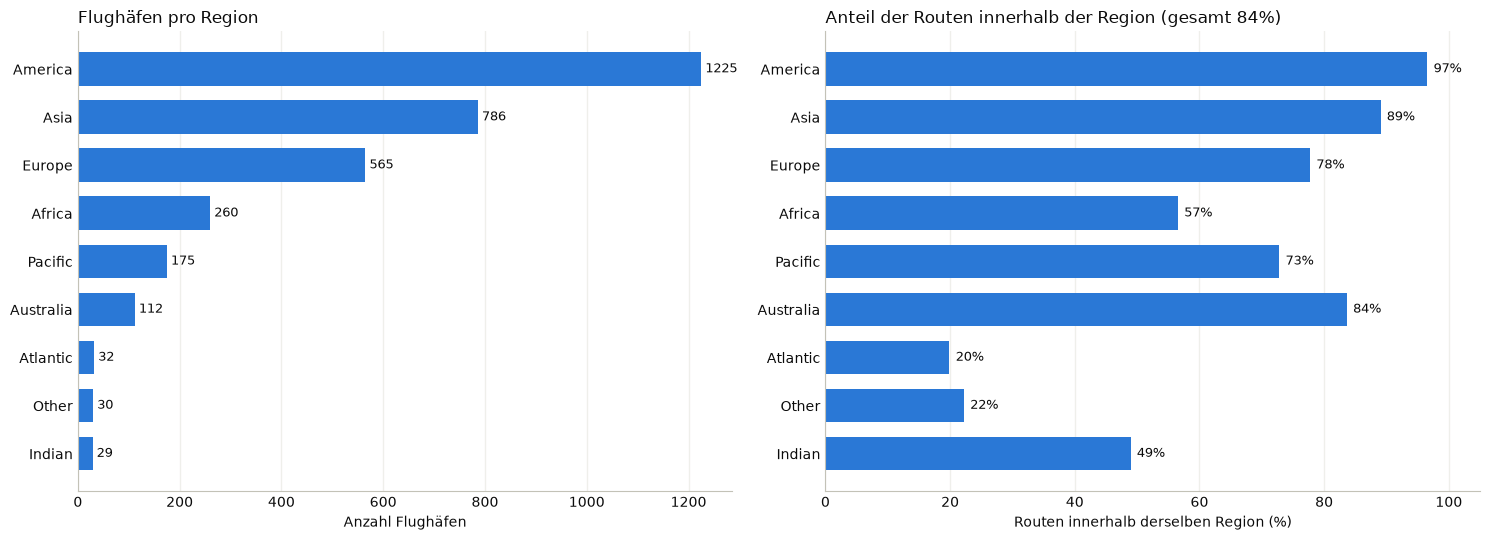

In [14]:
region_u = airports["region"].values[pairs["u_idx"]]
region_v = airports["region"].values[pairs["v_idx"]]
by_region = pd.DataFrame({
    "Flughäfen": airports["region"].value_counts(),
    "Routen (mind. ein Endpunkt)": pd.Series(np.r_[region_u, region_v]).value_counts(),
}).fillna(0).sort_values("Flughäfen")

fig, (ax1, ax2) = figure(1, 2, figsize=(15, 5.5))
ax1.barh(by_region.index, by_region["Flughäfen"], color=BLUE, height=0.7)
for y, v in enumerate(by_region["Flughäfen"]):
    ax1.text(v + 8, y, f"{int(v)}", va="center", fontsize=9, color=INK)
style(ax1, "Flughäfen pro Region", "Anzahl Flughäfen", None, grid_axis="x")

same = pd.Series(region_u == region_v).groupby(region_u).mean().reindex(by_region.index).fillna(0)
ax2.barh(same.index, same.values * 100, color=BLUE, height=0.7)
for y, v in enumerate(same.values):
    ax2.text(v * 100 + 1, y, f"{v:.0%}", va="center", fontsize=9, color=INK)
ax2.set_xlim(0, 105)
style(ax2, f"Anteil der Routen innerhalb der Region (gesamt {np.mean(region_u == region_v):.0%})",
      "Routen innerhalb derselben Region (%)", None, grid_axis="x")
fig.tight_layout()
plt.show()

## Kantenfeatures

Verteilungen der Kantenfeatures vor dem Skalieren. Die Zählgrößen sind stark rechtsschief und werden deshalb vor
dem `StandardScaler` mit `log1p` gestaucht.

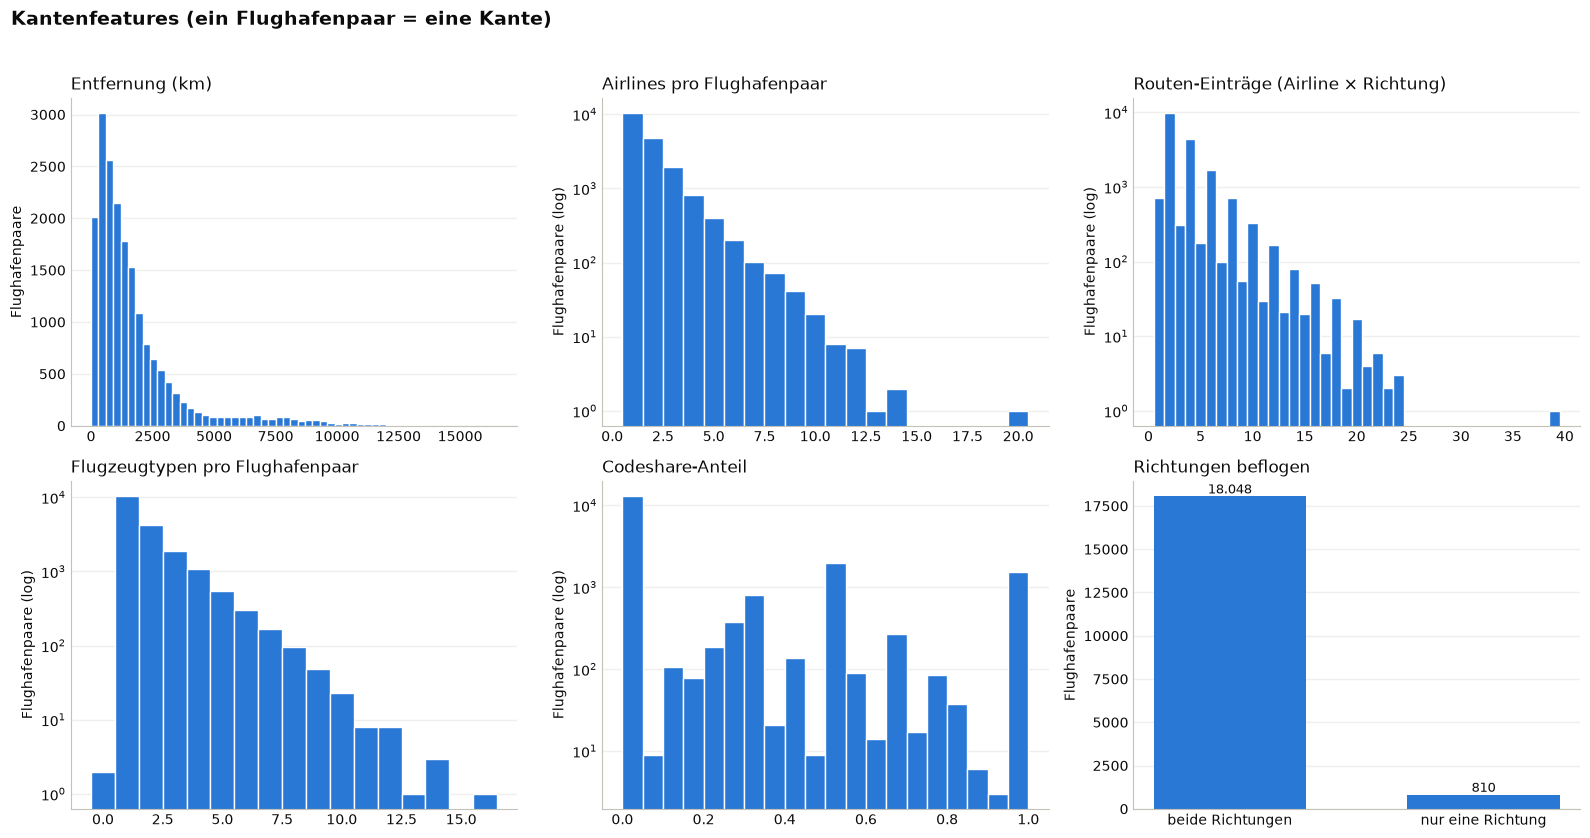

In [15]:
fig, axes = figure(2, 3, figsize=(16, 8.5))
specs = [
    ("distance_km", "Entfernung (km)", np.linspace(0, 16500, 56), False),
    ("n_airlines", "Airlines pro Flughafenpaar", np.arange(0.5, 21.5), True),
    ("n_route_entries", "Routen-Einträge (Airline × Richtung)", np.arange(0.5, 40.5), True),
    ("n_aircraft_types", "Flugzeugtypen pro Flughafenpaar", np.arange(-0.5, 17.5), True),
    ("codeshare_share", "Codeshare-Anteil", np.linspace(0, 1, 21), True),
]
for ax, (col, label, bins, log) in zip(axes.flat, specs):
    ax.hist(pairs[col], bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=1)
    if log:
        ax.set_yscale("log")
    style(ax, label, None, "Flughafenpaare" + (" (log)" if log else ""), grid_axis="y")
ax = axes.flat[5]
counts = pairs["bidirectional"].map({1: "beide Richtungen", 0: "nur eine Richtung"}).value_counts()
ax.bar(counts.index, counts.values, color=BLUE, width=0.6)
for x, v in enumerate(counts.values):
    ax.text(x, v, f"{v:,}".replace(",", "."), ha="center", va="bottom", fontsize=9, color=INK)
style(ax, "Richtungen beflogen", None, "Flughafenpaare", grid_axis="y")
fig.suptitle("Kantenfeatures (ein Flughafenpaar = eine Kante)", x=0.01, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Entfernung und Grad: Wer fliegt wohin?

Links: Routen von großen Hubs sind im Mittel deutlich länger (Langstrecke), kleine Flughäfen haben fast nur
Zubringer-Routen. Rechts: der Grad der beiden Endpunkte einer Route (log). Die meisten Routen verbinden zwei gut
vernetzte Flughäfen (dunkles Feld oben rechts). Kleine Flughäfen (linke Spalten) hängen an Flughäfen jeder Größe,
oft an einem regionalen Hub. Für die Link Prediction heißt das: Grad und Nachbarschaft beider Endpunkte sagen viel
darüber, ob eine Route existiert. Diese Information steckt nur im Graphen, nicht in den Knotenfeatures.

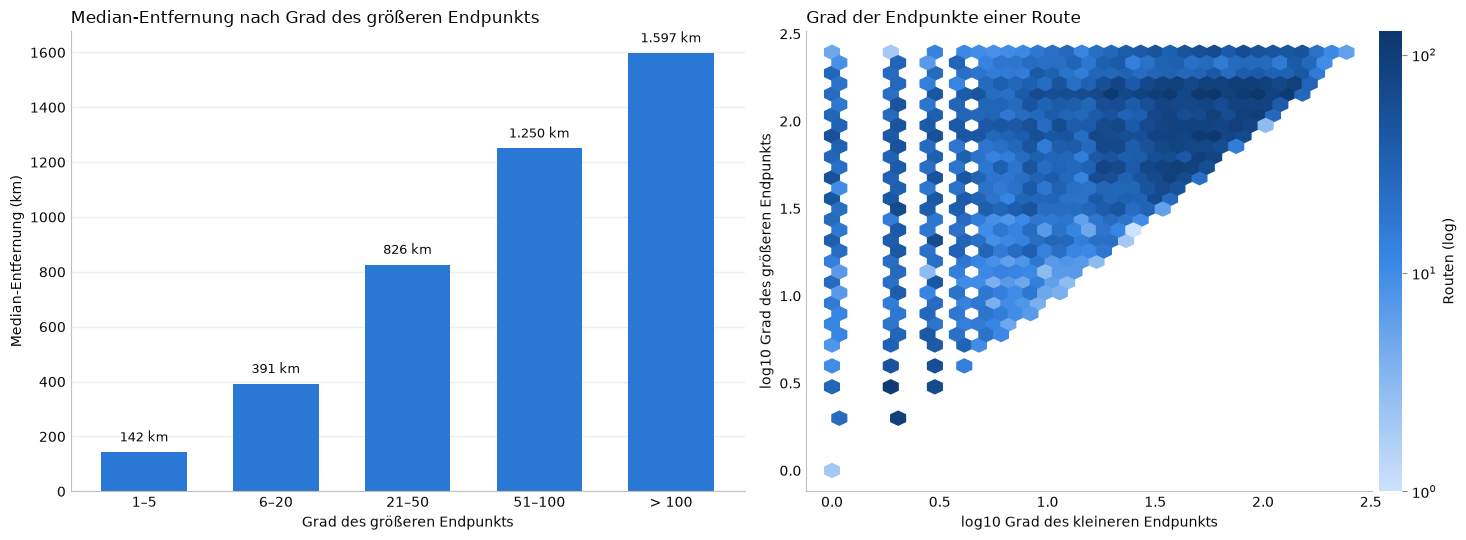

In [16]:
deg_arr = airports["degree"].values
pairs_plot = pairs.assign(max_deg=np.maximum(deg_arr[pairs["u_idx"]], deg_arr[pairs["v_idx"]]),
                          min_deg=np.minimum(deg_arr[pairs["u_idx"]], deg_arr[pairs["v_idx"]]))
bins = [0, 5, 20, 50, 100, 1000]
labels = ["1–5", "6–20", "21–50", "51–100", "> 100"]
pairs_plot["hub_class"] = pd.cut(pairs_plot["max_deg"], bins=bins, labels=labels)
median_dist = pairs_plot.groupby("hub_class", observed=True)["distance_km"].median()

fig, (ax1, ax2) = figure(1, 2, figsize=(15, 5.5))
ax1.bar(median_dist.index.astype(str), median_dist.values, color=BLUE, width=0.65)
for x, v in enumerate(median_dist.values):
    ax1.text(x, v + 40, f"{v:,.0f} km".replace(",", "."), ha="center", fontsize=9, color=INK)
style(ax1, "Median-Entfernung nach Grad des größeren Endpunkts", "Grad des größeren Endpunkts", "Median-Entfernung (km)", grid_axis="y")

hb = ax2.hexbin(np.log10(pairs_plot["min_deg"]), np.log10(pairs_plot["max_deg"]), gridsize=35, cmap=blues, mincnt=1, bins="log")
style(ax2, "Grad der Endpunkte einer Route", "log10 Grad des kleineren Endpunkts", "log10 Grad des größeren Endpunkts", grid_axis=None)
cbar = fig.colorbar(hb, ax=ax2, pad=0.01)
cbar.set_label("Routen (log)", color=INK); cbar.outline.set_visible(False); cbar.ax.tick_params(colors=MUTED, labelcolor=INK)
fig.tight_layout()
plt.show()

# Feature-Konfiguration

Hier wird festgelegt, was in `data.x` (Knoten) und `data.edge_attr` (Kanten) landet.

Verfügbare Knotenfeatures (Registry in `gnn_pipeline/openflights.py`):

| Name | Spalten | Beschreibung |
|---|---|---|
| `coords` | `sphere_x`, `sphere_y`, `sphere_z` | Position als Einheitsvektor (kein Sprung an der Datumsgrenze) |
| `altitude` | `log_altitude` | Höhe über dem Meer (log1p) |
| `timezone` | `utc_offset` | UTC-Offset in Stunden |
| `region` | `region_*` | One-Hot der Weltregion (9 Kategorien) |

Kontinuierliche Knotenfeatures werden standardisiert, die One-Hot-Spalten bleiben 0/1.
**Bewusst nicht enthalten:** Grad oder Zahl der Airlines pro Flughafen. Diese Größen werden aus den Routen
berechnet und würden Information über die Val-/Test-Kanten in die Knotenfeatures tragen (Leakage). Den Grad
muss das Modell selbst aus dem Message-Passing-Graphen ablesen.

**Kantenfeatures:** `distance_km`, `n_airlines`, `n_route_entries`, `n_aircraft_types` (log1p + StandardScaler),
dazu `codeshare_share` und `bidirectional` unverändert. Sie liegen nur auf den Kanten des Message-Passing-Graphen,
der Decoder sieht keine Features der zu bewertenden Kante.

In [17]:
print("Registrierte Knotenfeatures:", sorted(OPENFLIGHTS_NODE_FEATURES))

config = OpenFlightsConfig(
    node_features=["coords", "altitude", "timezone", "region"],
    edge_numerical=["distance_km", "n_airlines", "n_route_entries", "n_aircraft_types"],
    edge_plain=["codeshare_share", "bidirectional"],
)

SEED = 42
VAL_RATIO, TEST_RATIO = 0.1, 0.1
NEG_RATIO = 1.0            # ein Negativ pro Positivem (ausgewogene Klassen)
SUPERVISION_RATIO = 0.3    # Anteil der Train-Paare, die nur als Trainingslabels dienen (nicht im Graphen)
NEG_STRATEGY = "distance"  # Negative mit Loch und gleicher Entfernung wie echte Routen (siehe unten)
SPATIAL_K = 6              # bei "distance": Fenster von ±3 Rängen um die passende Entfernung

Registrierte Knotenfeatures: ['altitude', 'coords', 'region', 'timezone']


# Graph bauen, splitten, speichern

In [18]:
data, node_cols, edge_cols = build_openflights_graph(frames, config)
print(data)
print("Knotenfeatures:", node_cols)
print("Kantenfeatures:", edge_cols)

Data(x=[3214, 14], edge_index=[2, 37716], edge_attr=[37716, 6], pos=[3214, 3], num_nodes=3214)
Knotenfeatures: ['sphere_x', 'sphere_y', 'sphere_z', 'log_altitude', 'utc_offset', 'region_Africa', 'region_America', 'region_Asia', 'region_Atlantic', 'region_Australia', 'region_Europe', 'region_Indian', 'region_Pacific', 'region_Other']
Kantenfeatures: ['distance_km', 'n_airlines', 'n_route_entries', 'n_aircraft_types', 'codeshare_share', 'bidirectional']


## Split und Negative

Der Split (`split_graph` in `gnn_pipeline/graph.py`) hat drei Bausteine:

1. **Paarweise:** Beide Richtungen eines Flughafenpaars landen immer im selben Split (kein Leak über die
   Gegenrichtung).
2. **Ein gemeinsamer Message-Passing-Graph:** 70 % der Train-Paare bilden den Graphen, 30 % dienen nur als
   Trainingslabels. Train, Val und Test rechnen auf demselben Graphen, keine bewertete Kante liegt darin.
3. **Negative ohne Abkürzung (`NEG_STRATEGY = "distance"`, neu):** Bei zufälligen Negativen trennt schon die
   Luftlinie Routen von Nicht-Routen mit AUC ≈ 0.94, weil zufällige Flughafenpaare meist weit auseinander liegen.
   Negative unter den räumlich nächsten Knoten (`"hole"`) kehren das Problem bei
   Flugrouten um: Echte Routen sind oft lang, solche Negative immer kurz, und „weit weg = Route“ wird zur
   Abkürzung (AUC der Luftlinie ≈ 0.15, also umgekehrt ≈ 0.85). Bei `"distance"` stammen beide Endpunkte eines
   Negativs aus den Endpunkten der Positiven desselben Splits (gleiches „Loch“ wie bei `"hole"`), und der Partner
   wird so gewählt, dass die Entfernung zu der einer echten Route passt. Die Grafik unten zeigt die
   Entfernungsverteilungen.

Ein kleines Restsignal der Luftlinie (≈ 0.55) bleibt: Partner mit exakt passender Entfernung sind oft schon echte
Routen und werden verworfen.

In [19]:
train_data, val_data, test_data = split_graph(
    data, seed=SEED, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, neg_sampling_ratio=NEG_RATIO,
    neg_strategy=NEG_STRATEGY, spatial_k=SPATIAL_K, supervision_ratio=SUPERVISION_RATIO,
)

bundle = GraphBundle(
    data=data, train=train_data, val=val_data, test=test_data,
    node_feature_columns=node_cols, edge_attr_columns=edge_cols,
    node_type=airports["region"].tolist(),            # für die Einfärbung der Embeddings
    original_node_ids=airports["airport_id"].tolist(),
    meta={"dataset": "OpenFlights", "seed": SEED, "val_ratio": VAL_RATIO, "test_ratio": TEST_RATIO,
          "neg_sampling_ratio": NEG_RATIO, "neg_strategy": NEG_STRATEGY, "spatial_k": SPATIAL_K,
          "supervision_ratio": SUPERVISION_RATIO, "node_features": list(config.node_features),
          "edge_features": edge_cols, "split": "pair_aware"},
)
print(bundle.summary())
save_bundle(bundle, "processed/openflights_split.pt")

Knoten: 3214 {'America': 1225, 'Asia': 786, 'Europe': 565, 'Africa': 260, 'Pacific': 175, 'Australia': 112, 'Atlantic': 32, 'Other': 30, 'Indian': 29}, Kanten: 37716
Knotenfeatures (14): ['sphere_x', 'sphere_y', 'sphere_z', 'log_altitude', 'utc_offset', 'region_Africa', 'region_America', 'region_Asia', 'region_Atlantic', 'region_Australia', 'region_Europe', 'region_Indian', 'region_Pacific', 'region_Other']
Kantenfeatures (6): ['distance_km', 'n_airlines', 'n_route_entries', 'n_aircraft_types', 'codeshare_share', 'bidirectional']
train: msg-passing Kanten=21120, Label-Paare pos=9052 neg=9052
val: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
test: msg-passing Kanten=21120, Label-Paare pos=3772 neg=3772
train: positive Label-Kanten im Message-Passing-Graph: 0/9052, davon Gegenrichtung im Graph: 0/9052 (0.0%)
val: positive Label-Kanten im Message-Passing-Graph: 0/3772, davon Gegenrichtung im Graph: 0/3772 (0.0%)
test: positive Label-Kanten im Message-Passing-Graph: 0/3772, davo

'processed/openflights_split.pt'

In [20]:
# Kontrolle: keine bewertete Kante (und keine Gegenrichtung) liegt im Message-Passing-Graph
from gnn_pipeline import reverse_edge_leakage
from gnn_pipeline.graph import edges_in_graph

for name, split in [("train", train_data), ("val", val_data), ("test", test_data)]:
    assert edges_in_graph(split, split) == 0, f"{name}: Label-Kanten liegen im Message-Passing-Graph"
    leaked, total = reverse_edge_leakage(split, split)
    assert leaked == 0, f"{name}: {leaked} positive Kanten haben ihre Gegenrichtung im Message-Passing-Graph"
print("Keine Label-Kante und keine Gegenrichtung im gemeinsamen Message-Passing-Graph.")

Keine Label-Kante und keine Gegenrichtung im gemeinsamen Message-Passing-Graph.


## Entfernungen von Positiven und Negativen je Strategie

Test-Split, Großkreisentfernung der bewerteten Flughafenpaare. Nur bei `"distance"` liegen beide Verteilungen
übereinander.

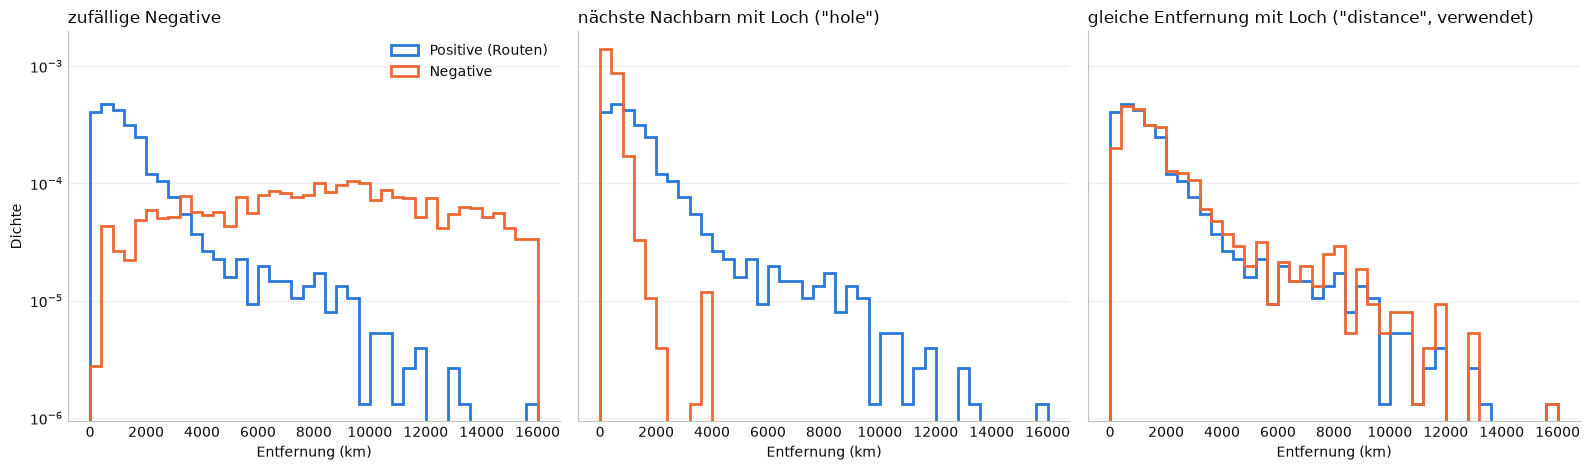

In [21]:
def pair_distance_km(split):
    u, v = split.edge_label_index
    chord = (split.pos[u] - split.pos[v]).norm(dim=1).numpy()
    return 2 * 6371 * np.arcsin(np.clip(chord / (2 * 6371), 0, 1))

strategy_splits = {"uniform": None, "hole": None, "distance": (train_data, val_data, test_data)}
for strategy in ("uniform", "hole"):
    strategy_splits[strategy] = split_graph(data, seed=SEED, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
                                            neg_sampling_ratio=NEG_RATIO, neg_strategy=strategy,
                                            spatial_k=20, supervision_ratio=SUPERVISION_RATIO)

fig, axes = figure(1, 3, figsize=(16, 4.8), sharey=True)
bins = np.linspace(0, 16000, 41)
titles = {"uniform": "zufällige Negative", "hole": "nächste Nachbarn mit Loch (\"hole\")",
          "distance": "gleiche Entfernung mit Loch (\"distance\", verwendet)"}
for ax, (strategy, splits) in zip(axes, strategy_splits.items()):
    test = splits[2]
    dist, label = pair_distance_km(test), test.edge_label.numpy()
    ax.hist(dist[label == 1], bins=bins, color=BLUE, histtype="step", linewidth=2, density=True, label="Positive (Routen)")
    ax.hist(dist[label == 0], bins=bins, color=ORANGE, histtype="step", linewidth=2, density=True, label="Negative")
    style(ax, titles[strategy], "Entfernung (km)", "Dichte" if strategy == "uniform" else None, grid_axis="y")
    ax.set_yscale("log")
axes[0].legend(frameon=False, labelcolor=INK)
fig.tight_layout()
plt.show()

## Heuristik-Baselines: Wie schwer ist die Aufgabe ohne Lernen?

ROC-AUC klassischer Link-Prediction-Heuristiken auf denselben Label-Paaren (berechnet auf dem gemeinsamen
Message-Passing-Graphen). Ein GNN muss diese Werte schlagen, sonst hat es nichts gelernt, was nicht schon eine
einfache Formel kann. Werte unter 0.5 bedeuten, dass die Heuristik umgekehrt funktioniert (1 − AUC).

- **-Distanz:** bei `"uniform"` ≈ 0.94 (Abkürzung), bei `"hole"` stark umgekehrt, bei `"distance"` ≈ 0.55.
- **Gemeinsame Nachbarn / Adamic-Adar:** echte Signale (viele Dreiecke im Netz), ≈ 0.75 bei `"distance"`.
- **Preferential Attachment** (Grad u · Grad v): Hubs verbinden sich häufiger, ≈ 0.70 bei `"distance"`.
- **Niedriger Grad (Loch):** umgekehrt (< 0.5), weil hier ein *hoher* Grad auf eine Route hinweist.

**Messlatte für die Modelle bei `"distance"`: Adamic-Adar ≈ 0.75–0.77.**

In [22]:
for strategy, splits in strategy_splits.items():
    print(f"neg_strategy={strategy!r}" + ("  <- verwendet" if strategy == NEG_STRATEGY else ""))
    display(heuristic_baselines(*splits).round(3))

neg_strategy='uniform'


,train,val,test
Heuristik,,,
-Distanz (Koordinaten),0.932,0.936,0.936
Gemeinsame Nachbarn,0.893,0.894,0.895
Adamic-Adar,0.895,0.895,0.896
Niedriger Grad (Loch),0.100,0.099,0.102
Preferential Attachment,0.878,0.875,0.871


neg_strategy='hole'


,train,val,test
Heuristik,,,
-Distanz (Koordinaten),0.133,0.160,0.176
Gemeinsame Nachbarn,0.730,0.790,0.829
Adamic-Adar,0.736,0.797,0.834
Niedriger Grad (Loch),0.215,0.140,0.119
Preferential Attachment,0.771,0.841,0.862


neg_strategy='distance'  <- verwendet


,train,val,test
Heuristik,,,
-Distanz (Koordinaten),0.547,0.548,0.568
Gemeinsame Nachbarn,0.773,0.742,0.742
Adamic-Adar,0.785,0.755,0.755
Niedriger Grad (Loch),0.308,0.317,0.333
Preferential Attachment,0.737,0.697,0.687
